In [242]:
import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

file_list = glob.glob(f"../../data/08_lead_lag/leadlag_df_*.csv")

df_list = []

for file_path in file_list:
    df_list.append(pd.read_csv(file_path, index_col=0))
df = pd.concat(df_list)

file_list = glob.glob("../../data/08_lead_lag/marketcap_leadlag_df_*.csv")
df_list = [pd.read_csv(file_path, index_col=0) for file_path in file_list]

df_mcap = pd.concat(df_list)

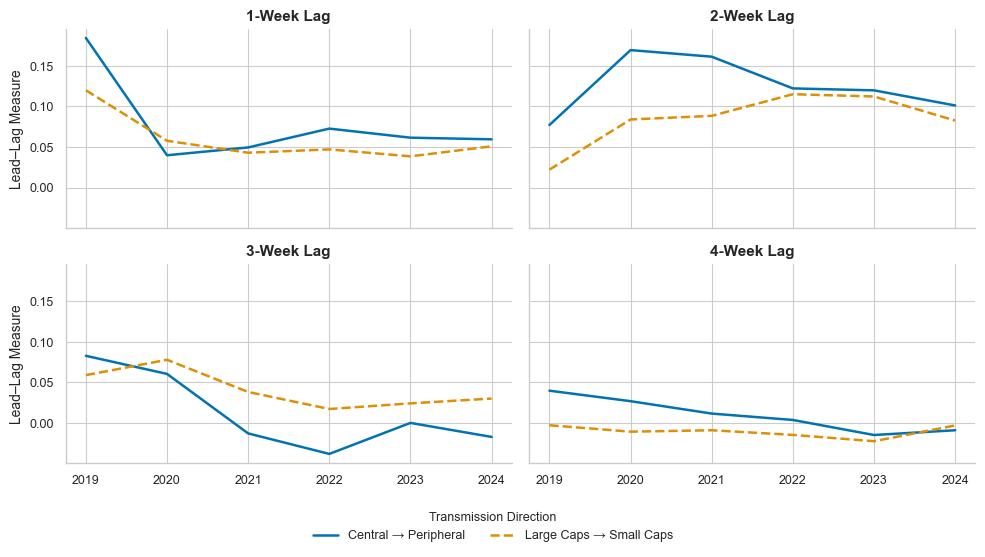

In [243]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# --- Style ---
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
palette = sns.color_palette("colorblind")

# --- Figure ---
fig, axes = plt.subplots(2, 2, figsize=(10, 5.5), sharex=True, sharey=True)
axes_flat = axes.flatten()  # ✦ key fix: iterate over individual axes

# -------- Panel config --------
panels = [
    ("cp1", "ls1", "1-Week Lag"),
    ("cp2", "ls2", "2-Week Lag"),
    ("cp3", "ls3", "3-Week Lag"),
    ("cp4", "ls4", "4-Week Lag"),
]

for i, (ax, (col_cp, col_ls, title)) in enumerate(zip(axes_flat, panels)):
    l1, = ax.plot(
        df.index, df[col_cp],
        lw=1.8, color=palette[0],
        label="Central → Peripheral"
    )
    l2, = ax.plot(
        df_mcap.index, df_mcap[col_ls],
        lw=1.8, color=palette[1], linestyle="--",
        label="Large Caps → Small Caps"
    )

    ax.set_title(title, fontsize=11, fontweight="bold", pad=6)
    ax.tick_params(axis="both", labelsize=9)
    ax.axhline(0, color="black", linewidth=0.6, linestyle=":", zorder=0)
    ax.set_xlabel("")

    # ✦ Only left-column panels get a y-label
    if i % 2 == 0:
        ax.set_ylabel("Lead–Lag Measure", fontsize=10)
    else:
        ax.set_ylabel("")

# -------- Single shared legend below all panels --------
handles = [l1, l2]
fig.legend(
    handles,
    [h.get_label() for h in handles],
    loc="lower center",
    ncol=2,
    frameon=False,
    fontsize=9,
    title="Transmission Direction",
    title_fontsize=9,
    bbox_to_anchor=(0.5, -0.02),
)

# -------- Final polish --------
sns.despine(fig=fig)
plt.tight_layout(rect=[0, 0.07, 1, 1])
plt.show()